# **Online Retail Sales Prediction**

## **Machin learning Analysis**

## Objectives

* Develop a machine learning solution for an online retail sales prediction problem.
* Use the cleaned Online Retail dataset prepare during the ETL and data analysis stage.
* Explore and prepare relavant features for machine learning.
* Apply appropriate statistical and data analysis techniques before modelling.
* Implement a supervised machine learning regression algorithm using Scikit learn.
* Train and compare suitable machine learning models.
* Evaluate model performance using appropriate regression matrics.
* visualise and interpret the prediction results.
* validate the project hypothesis using the model results.
* Identify limitations and provide recommendations for future improvement.
* Translate the analytical findings into useful business recommendations for sales and planning.
## Inputs

* The main input for this machine learning analysis is the cleaned Online Retail transaction dataset produced during the ETL stage of the project.

The dataset contains :

* Invoice number
* Product/stock code
* Product description
* Quantity purchased
* Invoice date
* Unit price
* Customer ID
* Country

The clean dataset will be loaded from:
'Dataset/CleanData/Online_Retail_cleaned.csv'

The machine learning analysis will use the cleaned data to create relavant features and a suitable target variable for sales perdictions.

## Outputs

* Prepare dataset suitable for machine learning.
* Engineered features for sales pediction.
* Defined target variable representing sales.
* Trained baseline and machine learning regression model.
* Model performence measurements.
* Comparison of model performance.
* Visualisations showing actual and predicted sales.
* Feature importance or model interpretation where appropriate.
* Hypothesis validation based on the model results.
* Limitations and potantial improvements.
* Business recommendations based on the predictive analysis.

## Additional Comments

 The machine learning work builds on the data preparation, exploratory analysis and visualisation completed in the earlier stages of the project.

A supervised learning approch will be used because the objective is to predict a numerical sales outcome from historical retail data.  

The modelling approch will be selected and justified based on the business problem, characteristics of the dataset and suitability of the available features.

Model performance will be evaluated using unseen test data rather than relying only on training performance. 


---

# Business Problem

## Online Reatil Sales Predition

The business has historical online retail transaction containing informations about products, quantities, transaction dates, prices, customers and countries. 

The previous stages of the project identified patterns in sales, products, customers and geographical markets. 

The next stage is to investigate whether historical transactions information can be used to predict future sales. 

### Business questions

* Can historical online retail transaction data be used to predict transaction value ?
* Which feature has the greatest influence on predicted transaction value?

### Analytical problem 

This is supervised machine learning problem because historical observation contain known sales outcomes that can be used to train a model to predict future numerical sales values.

## Hypothesis

### Alternative Hypothesis (H1)
Historical online retail transaction data contains predictive information that can be used to estimate future transaction values with meaningful predictive performance.

### Null Hypothesis (H0)
Historycal online retail transaction data does not contain sufficient predictive information to estimate future transaction values with meaningful predictive performance. 


# Change working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [13]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\Pdhar\\OneDrive\\Documents\\GitHub\\Online_Retail_Transaction_Analysis'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [14]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [15]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\Pdhar\\OneDrive\\Documents\\GitHub'

# Section 1

Section 1 content

In [16]:
# Import libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score



## Load the cleaned dataset
The clean Online Retail Dataset will be loaded into a pandas DataFrame. This dataset will be used for the machine learning analysis and sales prediction.

In [17]:
file_path = (r"C:\Users\Pdhar\OneDrive\Documents\GitHub\Online_Retail_Transaction_Analysis\Dataset\CleanData\Online_Retail_Cleaned.csv")
df = pd.read_csv(file_path)
print("Dataset loaded successfully.")
print("Shape:",df.shape)
df.head()

Dataset loaded successfully.
Shape: (524878, 9)


C:\Users\Pdhar\AppData\Local\Temp\ipykernel_14828\2159172201.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


### Dataset Loading Results 

The cleaned Online Retail dataset was successfully loaded into the Jupyter Notebook.

The dataset contains 524,878 transaction records and 9 variables. The variables include invoice information, product details, quantity purchased, invoice date, unit price, customer information, country and total amount.

The total amount variable will be particularly important for the sales prediction task because it represents the value of each transaction.

The dataset now ready for further data inspection, preparation and machine learning analysis.

## Dataset Inspection

Before developing the machine learning model, the dataset will be inspected to understand its structure, data types, missing values and basic statistical characteristics. This will help identify any issues that need to be addressed before modelling. 

In [18]:
# Inspect the dataset

print("Dataset information:")
df.info()
print("\nmissing values:")
print(df.isnull().sum())

print("\nBasic statistical summry:")
display(df.describe(include="all"))

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524878 entries, 0 to 524877
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    524878 non-null  object 
 1   StockCode    524878 non-null  object 
 2   Description  524878 non-null  object 
 3   Quantity     524878 non-null  int64  
 4   InvoiceDate  524878 non-null  object 
 5   UnitPrice    524878 non-null  float64
 6   CustomerID   524878 non-null  int64  
 7   Country      524878 non-null  object 
 8   TotalAmount  524878 non-null  float64
dtypes: float64(2), int64(2), object(5)
memory usage: 36.0+ MB

missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

Basic statistical summry:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
count,524878.0,524878,524878,524878.000000,524878,524878.000000,524878.000000,524878,524878.000000
unique,19962.0,3922,4026,NaN,18499,NaN,NaN,38,NaN
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2011-10-31 14:41:00,NaN,NaN,United Kingdom,NaN
freq,1114.0,2253,2311,NaN,1114,NaN,NaN,479985,NaN
mean,NaN,NaN,NaN,10.616600,NaN,3.922573,15287.631345,NaN,20.275399
std,NaN,NaN,NaN,156.280031,NaN,36.093028,1482.145530,NaN,271.693566
min,NaN,NaN,NaN,1.000000,NaN,0.001000,12346.000000,NaN,0.001000
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,14375.000000,NaN,3.900000
50%,NaN,NaN,NaN,4.000000,NaN,2.080000,15287.000000,NaN,9.920000
75%,NaN,NaN,NaN,11.000000,NaN,4.130000,16245.000000,NaN,17.700000


### Dataset inspection results

The dataset contains 524,878 transactions and 9 variables. The inspections shows that there are no missing values treatment is required at this stage.

The dataset contains both numerical and categorical variables, while Invoiceno, Stockcode, Discription and Country contain categorical or text information.
Invoice is a date-time variable.

The TotalAmount variable will be used as the target variable for the online retail sales prediction model. The remaining relevant variables will be assessed and prepared as input features during the preprocessing stage.

This inspection confirms that the dataset is suitable for the next stage of the project: data preprocessing and feature preparation for machine learning.

## Data preprocessing and Feature Preparation

Before applying machine learning, the dataset must be prepared so that the relavant variables can be used as model inputs.

The InvoiceDate variable will be converted into useful data based features such as year, month, day and hour. Numerical variables such as 'Quantity' and 'UnitPrice' will be retained as potatial predictors.

The 'Country' variable will be converted into numerical dummy variables so that it can be used by the machine learning algorithms.

'InvoiceNo', 'StockCode' and 'Description' will not be used direct model features because they are identifiers or text descriptions rather than meaningful numerical predictors.

The target variable for this project is 'TotalAmount' representing the value of an individual retail transaction.

In [19]:
# Converted InvoiceDate to date time format
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create date based features
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour
df["DayOfWeek"] = df["InvoiceDate"].dt.dayofweek

# Display the new features
df[["InvoiceDate","Year","Month","Day","Hour","DayOfWeek"]].head()

,InvoiceDate,Year,Month,Day,Hour,DayOfWeek
0,2010-12-01 08:26:00,2010,12,1,8,2
1,2010-12-01 08:26:00,2010,12,1,8,2
2,2010-12-01 08:26:00,2010,12,1,8,2
3,2010-12-01 08:26:00,2010,12,1,8,2
4,2010-12-01 08:26:00,2010,12,1,8,2


### Date Feature Preparation

The 'InvoiceDate' column has been coverted into a datetime formate. Additional features have been created for year, month, day, hour and day of the week.

These features may help the model identify pattern in transaction values based on when purchases occured.

The original 'InvoiceDate' column will not be used directly by the regression models. Instead, the extracted numerical date features will be used as model inputs.

---

## Define Input Features and Target Variable

For the machine learning task 'TotalAmount' will be treated as the target variable that the model attempts to predict.

The selected input features include transaction quantity, unitprice, customer information, country and the data based features created during preprocessing.

Identifier and free text columns are excluded because they are not appropriate direct predictors for this model.


In [20]:
# Select the input features
features = ["Quantity", "UnitPrice", "Year", "Month", "Day", "Hour", "DayOfWeek", "Country"]

# Create the feature date
X =df[features].copy()

# Define the target variable
y = df["TotalAmount"].copy()

# Converted country into dummy variables
X = pd.get_dummies(X, columns=["Country"], drop_first=True)

print("Feature dataset shape:",X.shape)
print("Target dataset shape:",y.shape)
X.head()

Feature dataset shape: (524878, 44)
Target dataset shape: (524878,)


,Quantity,UnitPrice,Year,Month,Day,Hour,DayOfWeek,Country_Austria,Country_Bahrain,Country_Belgium,...,Country_RSA,Country_Saudi Arabia,Country_Singapore,Country_Spain,Country_Sweden,Country_Switzerland,Country_USA,Country_United Arab Emirates,Country_United Kingdom,Country_Unspecified
0,6,2.55,2010,12,1,8,2,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,6,3.39,2010,12,1,8,2,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,8,2.75,2010,12,1,8,2,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,6,3.39,2010,12,1,8,2,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,6,3.39,2010,12,1,8,2,False,False,False,...,False,False,False,False,False,False,False,False,True,False


### Feature and Target Preparation Results
The feature preparation was completed successfully. The dataset contains 524,878 observations, and the input feature dataset contains 4 4variable after converting the categorical 'Country' variable into numerical dummy variables.

The target variable is 'TotalAmount' containing 524,878 observations. This represents the transaction sales amount that the machine learning models will attempt to predict.

The original categorical country information has been transformed into numerical variables, making it suitable for machine learning algorithms. The selected numerical and date based features will now be used for model training and evaluation.

The prepared feature dataset provides the required inputs for the next stage : splitting the data into training and testing sets.

# Section 2

---

## Training and Testing Data

The prepared dataset will now be divided into training and testing datasets.

An 80/20 split will be used. The training dataset will be used to train the machine learning models, while the testing dataset will be used to evaluate their performance on unseen data. 

A fixed random state is used to make the results reproducible.

---

In [21]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("Training features:",X_train.shape)
print("Testing features:",X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (419902, 44)
Testing features: (104976, 44)
Training target: (419902,)
Testing target: (104976,)


### Training and Testing Split Results

The dataset was successfully divided into training and testing sets using an 80/20 split.

The training set contains 419,902 obsevations and 44 input features. The testing set contains 104,976 observations and the same 44 input features.

The training data will be used to fit the machine learning models, while the testing data will be used to evaluate how accurately the models predict 'TotalAmount' for previously unseen transactions.

The fixed random state of 42 ensures that the same training and testing split can be reproduced when the analysis is run again.

The data is now prepared for the machine learning modelling stage.

## Train the machine learning model training

This project uses supervised machine learning because the target variable, 'TotalAmount'is known in the training dataset.

The objective is to predict the total sales amount of an online retail transaction using the prepared input features. 

Two regression algorithm will be implemented:
1. Linear Regression used as a baseline model to identify the linear relationship between the input variables and 'TotalAmount'.
2. Random forest Regression used as a more flexible model that can capture non linear relationships between the input variables and the target.

The performance of both model will be evaluated using the testing dataset. The models will then be compared to determine which approach provides the more effective prediction.


In [22]:
# Train the linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the testing data
linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")
print("Number of predictions:", len(linear_predictions))

Linear Regression model trained successfully.
Number of predictions: 104976


### Linear Regression Training  Result

The linear regression model was successfully trained using the training dataset.

The model generated predictions for all 104,976 observations in the testing dataset. These predictions will be compared with the actual 'TotalAmount' values to evaluate the accuracy of the model.

Linear Regression provides a useful baseline because it assumes that the relationship between the selected input features and the target variable can be represented using a linear relationship.



## Linear Regression Model Evaluation

The linear regression model will now be evaluated using three performance metrics:

* Mean Absolute Error(MAE) measures the average absolute differance between the predicted and actual sales amounts.
* Mean Squared Error(MSE) gives greater weight to larger predictions errors.
* R2 Score measures how much of the variation in the target variable is explained by the model.

Lower MAE and MSE values indicate smaller prediction errors while a higher R2 score indicates better explanatory performance.

In [23]:
# Evaluate Linear Regression

linear_mae = mean_absolute_error(y_test,linear_predictions)
linear_mse = mean_squared_error(y_test,linear_predictions)
linear_r2 = r2_score(y_test,linear_predictions)

print("Linear Regression Performance")
print(".............................")
print(f"MAE: {linear_mae:.2f}")
print(f"MSE: {linear_mse:2f}")
print(f"R2 Score: {linear_r2:.4f}")


Linear Regression Performance
.............................
MAE: 10.80
MSE: 2845.867170
R2 Score: 0.5765


### Linear Regression Evaluation Results

The Linear Regression model achieved an MAE of 10.80, meaning that the model's predictions differ from the actual 'TotalAmount' values by approximatley 10.80 units on average.

The MSE was 2845.87. This metric gives greater weight to larger prediction errors, so it indicates that some transactions have larger differences between their predicted and actual sales amounts.

The R2 Score was 0.5765, meaning that the model explaines approximately 57.65% of the variant in total amount within the testing dataset.

Overall, the linear Regression model provides a reasonable baseline for the online retail sales prediction problem. However, there is still unexplained variation in the target variable, so a more flexible model will be tested next.

The Linear Regression result will therefore be compared with a Random Forest Regression model to determine whether a more complex machine learning approach can improve predictive performance.

## Random Forest Regression

A Random Forest Regression model will now be implemented as a second supervised machine learning approch.

Random Forest uses multiple decision trees to make predictions and can identify more complex and non linear relationships between the input features and the target variable.

The Random Forest model will be trained using the same training dataset used for linear Regression. Its prection will then be evaluated using MAE, MSE and R2 Score. 

Using the same evaluation metrics allows a fair comparison between the two models.

In [24]:
# Train the Random Forest Regression model

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train,y_train)

# Make predictions on the testing data

rf_predictions = random_forest_model.predict(X_test)

print("Random Forest Regression model trained successfully.")
print("Number of predictions:", len(rf_predictions))

Random Forest Regression model trained successfully.
Number of predictions: 104976


## Random Forest Training Results
The Random Forest Regression model was successfully trained using the training dataset.

The model generated predictions for all 104,976 observations in the testing dataset.

The prediction will now be evaluted using Mean Absolute Error(MAE), Mean Squared Error (MSE) and R2  score. These result will be compared with the Linear Regression results to determine which model provides better predictive performance.




## Random Forest Model Evaluation

The Random Forest Regression model will be evaluated using the same three performence measures used for Linear Regression.

MAE measure the average absolute prediction error while MSE gives greater weight to larger errors. The R square score measures the proportion of variation in 'TotalAmount' explained by the model.

For this project, lower MAE and MSE  values and a higher R square score indicate better predictive performance.

In [25]:
# Evaluate Random Forest  Regression

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test,rf_predictions)
rf_r2 = r2_score(y_test,rf_predictions)

print("Random Forest Regression Performance")
print("....................................")
print(f"MAE: {rf_mae:.2f}")
print(f"MSE: {rf_mse:2f}")
print(f"R2 score: {rf_r2:.4f}")

Random Forest Regression Performance
....................................
MAE: 0.23
MSE: 204.325690
R2 score: 0.9696


### Random Forest Regression Result 
The Random Forest Regression model achieved an MAE of **0.23** and an MSE of **204.33**. These relatively low error values indicate that the model makes accurate predictions of 'TotalAmount'.

The model achived an R square of **0.9696**, meaning that approximately **96.96% of the variation in 'TotalAmount' is explained by the input features**.

Overall, the Random Forest Regression model demonstrates strong predictive performance on the test dataset.

### Hypothesis validation

The hypotheses were evaluated using the performance of the Random forest regression model. Model performance was assessed using R2, MAE, and MSE. The result were used to determine whether historical transaction information provided sufficient predictive information for estimating transaction values. 

## Comparison of Machine learning Models
 Two regression models were developed to predict the 'TotalAmount' variable: Linear Forest Regression.

 The models were evaluated using Mean Absolute Error(MAE), Mean Squared Error (MSE), and R square score. These metrics allow the predictive performance of the two model to be compared using the same testing dataset.

In [26]:
# Compare the performance of the two regression models

comparison = pd.DataFrame({"Model":["Linear Regression",
                                     "Random Forest Regressor"],
                            "MAE": [linear_mae, rf_mae],
                            "MSE": [linear_mse, rf_mse],
                            "R2 score":[linear_r2, rf_r2]})

comparison

,Model,MAE,MSE,R2 score
0,Linear Regression,10.80463,2845.86717,0.576542
1,Random Forest Regressor,0.23336,204.32569,0.969597


## Interpretation of Model Comparison

The comparison shows that the Random Forest Regression model performs better than the Linear Regression model on the testing dataset.

The Linear Regression model achieved an MAE of approximately 10.80, an MSE of approximately 2845.87 and an R2 score of 0.5765.

In comparision, the Random Forest Regression model achieved a much lower MAE of approximately 0.23, an MSE of approximately 204.33, and a higher R square score of 0.9696.

Lower MAE and MSE indicate smaller prediction errors, while a higher R2 score indicates that the model explains more of the variation in the 'TotalAmount'.

Therefore, Random Forest Regression is the better performing model for predicting 'TotalAmount' in this analysis.




## Feature Importance Analysis 

The Random Forest model can be used to identify which input features contribute most to predicting 'TotalAmount'.

Feature importance measures the relative contribution of each input feature to the model's predictions. Analysing feature importance helps identify the variables that are most influential in predicting transaction value and provides additional insight into customer purchasing behaviour.

In [27]:
# Feature importance analysis for the Random Forest model

feature_importance = pd.DataFrame({"Feature": X.columns,
                                   "Importance":
                                   random_forest_model.feature_importances_})
# Sort features from most to least important

feature_importance = feature_importance.sort_values(by="Importance",
                                                    ascending=False)

print("Top 10 Most Important Features:")
display(feature_importance.head(10))

Top 10 Most Important Features:


,Feature,Importance
0,Quantity,0.850992
1,UnitPrice,0.124754
3,Month,0.008450
4,Day,0.005761
6,DayOfWeek,0.005287
5,Hour,0.004668
42,Country_United Kingdom,0.000024
2,Year,0.000021
30,Country_Netherlands,0.000018
22,Country_Hong Kong,0.000013


C:\Users\Pdhar\AppData\Local\Temp\ipykernel_14828\850272819.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


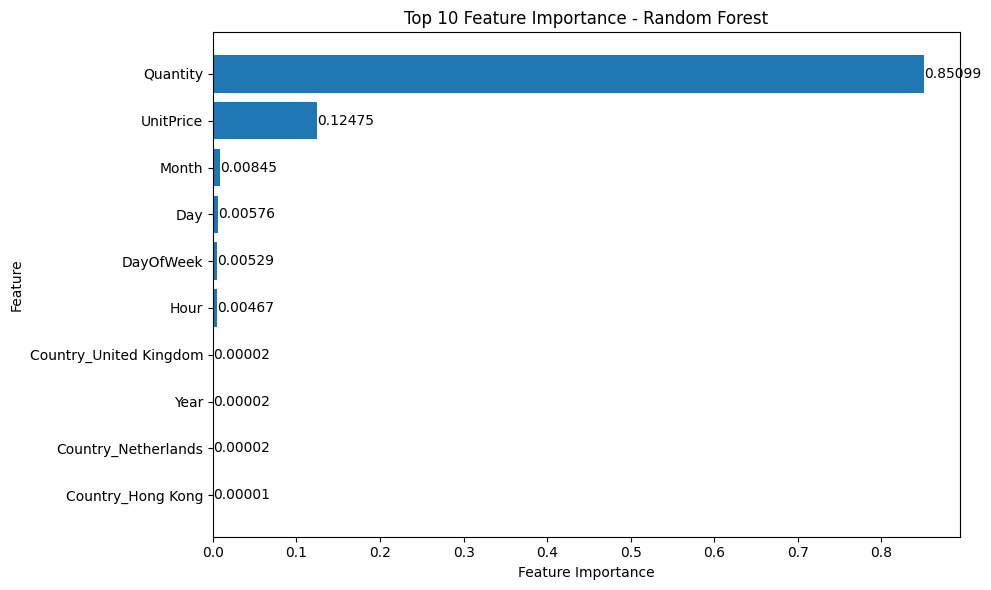

In [35]:
import matplotlib.pyplot as plt 
import pandas as pd
top_features = feature_importance.head(10).copy()

top_features["Importance"]= pd.to_numeric(top_features["Importance"])

top_features = top_features.sort_values(by="Importance", ascending=True)
# Create the figure and axes
fig, ax = plt.subplots(figsize=(10,6))
# Horizontal bar chart
bars = ax.barh(
    top_features["Feature"],
    top_features["Importance"]
)
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")
ax.set_title("Top 10 Feature Importance - Random Forest")

# Add values to bars
for bar in bars:
    value = bar.get_width()
    ax.text(
        value,
          bar.get_y() + bar.get_height()/2,
                                   f"{value:.5f}",
                                   va="center")

fig.tight_layout()
fig.show()

### Interpretation of Feature Importance

The Feature importance analysis shows that 'Quantity' is the most impotant feature for predicting 'TotalAmount' with an impotance score of approximately **0.851**. This indicates that the quantity of products purchased has the strogest influence on the model's predictions.

'UnitPrice' is the second most impotant feature with an important score of approximately **0.125**. This suggests that the price of an individual product also has a substaintial influence on the predicted transaction value.

The time related festures including Month, Day, DayOfWeek, and Hour have relatively small importance scores. The Country features have very low impotance scores compared with Quantity and UnitPrice.

Overall, the results suggest that transaction value is primarily influenced by the Quantity purchsed and UnitPrice. These findings provide useful business insight because increasing the quantity purchased or the price of products directly affects the total transaction value. 

Feature importance indicates how useful each feature was to the Random Forest model's predictions, but it does not necessarily imply a causal relationship. Therefore , the results should be interpreted as predictive relationships rather than evidence that these features directly cause changes in transaction value.

## Actual vs Predicted Values 

To further evaluate the Random Forest Regression model, the actual 'TotalAmount' values are compared with the values predicted by the model.

A scatter plot is used to visualise the relationship between actual and predicted values. Points closer to the diagonal reference line indicate more accurate predictions.

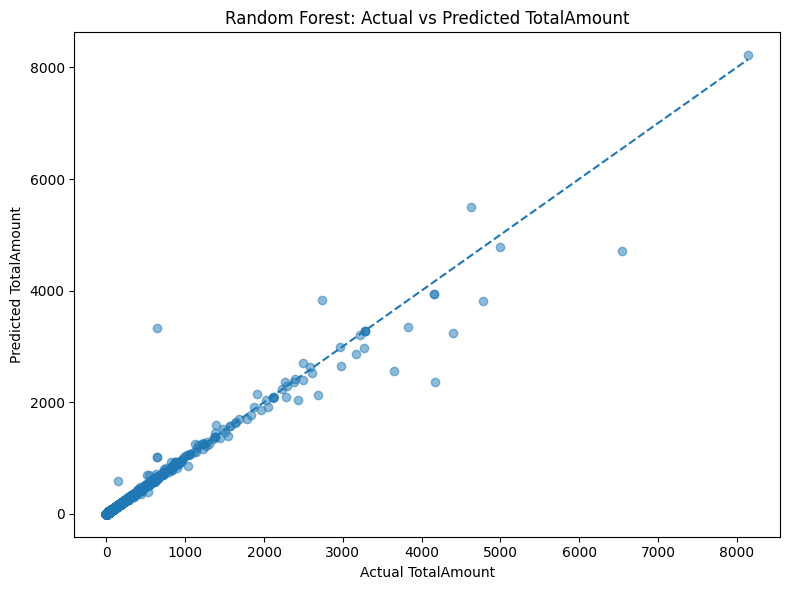

In [29]:
# Actual vs Predicted values for Random Forest Regression

import matplotlib .pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_predictions, alpha=0.5)

# Reference line: perfect predictions

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 
         linestyle="--")

plt.xlabel("Actual TotalAmount")
plt.ylabel("Predicted TotalAmount")
plt.title("Random Forest: Actual vs Predicted TotalAmount")
plt.tight_layout()
plt.show()

### Interpretation of Actual vs Predicted values

The scatter plot compares the actual 'TotalAmount' values with the values predicted by the Random Forest Regression model.

The dashed diagonal line represents perfect predictions where the predicted value is equal to the actual value. Most of the points are located close to this line, indicating that the Random Forest model provides accurate predictions for most transactions.

Some points are further away from the reference line, showing that the model makes larger prediction errors for some transactions, particularly for higher transaction values. 

Overall, the visualisation supports the evaluation results. The Random Forest model achieved an R square score of approximately 0.970, indicating strong predictive performance on the test dataset.


## Business Findings 

The analysis indicates that historical online retail transaction data can be used to predict transaction value using a Random Forest Regression model.

The Random Forest model performed better than the Linear Regression model based on the model evaluation results. The Random Forest model achieved an R2 score of 0.9696, an MAE of approximately 204.33.

The feature importance analysis showed that Quantity was the most influential feature , followed by UnitPrice. This indicates that the number of products purchased and the unit price are  the most important features used by the model when predicting transaction value.

The Actual vs Predicted visualisation showed that many predicted transaction values were close to the actual values, although some larger transactions showed greater differences.

These findings provide useful evidence for understanding the factors associated with transaction value and can support business decisions around sales planning, product management and customer analysis.

## Method Selection, Limitations and Alternative Approaches
### Why Random Forest Regression was selected ?

The target variable 'TotalAmount' is a continuous numerical variable, making regression an appropriate machine learning approach.

Random Forest was selected because it can capture non linear relationships and interactions between features. It also provides future importance values, which help identify the variables that contribute most to the model's predictions.

Linear regression also used as a based line model for comparision. The random forest model achive better predictive performance based on the evaluation results including MAE, MSE and R2. Therefore Random Forest Regression was selected as the preferred model for this project.

### Limitations
The model was trained using historical online retail transaction data, so its predictions may not fully represent future changes in customer behaviour or market conditions.

Some higher value transactions show larger differences between actual and predicted values. In addition, feature importance indicates which variables are useful for prediction but does not prove that those variables directly cause changes in transaction value.


### Alternative Approaches
Other regression approches could be explored in future work, such as Decision Tree Regression or Gradient Boosting  Rregression.

The model could also potentially be improved through hyperparameter turning, cross validation and additional feature engineering.

Overall, Random Forest Regression was considered an appropriate method for the current business problem because it provided stronger predictive performance than the Linear Regression baseline.

## Machine Learning Conclusion

The machine learning analysis investigated whether historical online retail transaction data could be used to predict transaction value. 

Two regression models were developed and compared: Linear Regression and Random Forest Regression. The Random Forest model was selected as the preferred model because it achieved stronger prective performance than the Linear Regression model based on the evaluation results. 

The Random Forest model achieved an R2 score of 0.9696, an MAE of approximately 0.23, and an MSE of approximately 204.33. The Actual vs Predicted visualisation also provided evidence that many predicted transaction values were close to the actual values. 

The feature importance analysis identified 'Quantity' as the most influential feature , followed by 'UnitPrice'. This provides additional insight into the factors that the model considers important when predicting transaction value.

Overall, the results provide evidence that historical online retail transaction data can be used to develop a useful predictive model for transaction value. The findings can support further business analysis and decision making around sales and product management.

## Learning Journey and Adaptation

* This project improved my understanding of how machine learning can be applied to a real-world online retail problem. I learned how to move from a business question to a machine learning solution.
* One challenge was preparing the dataset and selecting suitable features. I overcame this by reviewing the data carefully and creating relevant features for predicting transaction value.
* I learned how to use Python, pandas, matplotlib and scikit learn to prepare data, build models and create visualisations. This improved my practical technical skills.
* Another challenge was selecting and comparing suitable machine learning models. Comparing Linear Regression and Random Forest Regression helped me understand why different models can produce different results.
* I also learned that evaluating a model is important rather than relying only on predictions. Using R2, MAE and MSE helped me assess model performance and understand the strengths and limitations of the approach.
* Overall, this project has prepared me for future work in data analytics by improving my ability to learn new tools, adapt to different methodologies, evaluate analytical results and communicate findings to support data driven
decisions.  

## Future Improvements / Next Steps

Future work could improve the model through hyperparameter tuning, cross validation and additional feature engineering.Testing the model with new data could also help determine whether its predictive performance remains reliable overtime. Alternative regression algorithms could be investigated and compared with Random Forest Regression.

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [30]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)